In [1]:
import jax
import jax.numpy as jnp
from jax import vmap, jit
from jax.random import PRNGKey, split, poisson, uniform, normal
from functools import partial
from jax.scipy.ndimage import map_coordinates

print(f"JAX is running on: {jax.default_backend()}")

# --- 1. Setup & Mock Data ---
key = PRNGKey(42)
key, subkey1, subkey2, subkey3, subkey4 = split(key, 5)

# NUM_HALOS = 1000000
# halo_catalog = {
#     'ra': uniform(subkey1, (NUM_HALOS,), minval=0.0, maxval=360.0),
#     'dec': uniform(subkey2, (NUM_HALOS,), minval=-90.0, maxval=90.0),
#     'z': uniform(subkey3, (NUM_HALOS,), minval=0.1, maxval=1.5),
#     'mass': 10**uniform(subkey4, (NUM_HALOS,), minval=11.5, maxval=15.0)  # M200c in M_sun/h
# }



JAX is running on: gpu


In [3]:
import pathlib
import sys, os
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)
import yaml
from godmax.get_radial_profiles import Profiles

def read_yaml(file_path):
    with open(file_path, 'r') as file:
        data = yaml.safe_load(file)
    return data

def generate_dicts(data):
    sim_params_dict = data.get('sim_params', {})
    halo_params_dict = data.get('halo_params', {})
    analysis_dict = data.get('analysis', {})
    other_params_dict = data.get('other_params', {})
    return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict

yaml_file_path = '/mnt/home/spandey/ceph/GODMAX/param_files/params_default.yaml'
data = read_yaml(yaml_file_path)
sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(data)

halo_params_dict['rmin'] = 0.0001
halo_params_dict['rmax'] = 10.0
halo_params_dict['nr'] = 126
halo_params_dict['zmin'] = 0.01
halo_params_dict['zmax'] = 2.1
halo_params_dict['nz'] = 127
halo_params_dict['lg10_Mmin'] = 12.0
halo_params_dict['lg10_Mmax'] = 16.0
halo_params_dict['nM'] = 128

cosmo_params_dict = {'w0':-1.0 ,'flat': True, 'H0': 67.74, 'Om0': 0.3089, 'Ob0': 0.0486, 'sigma8':0.8159 ,'ns': 0.9667}

Prof_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)



/mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/site-packages/jax/_src/numpy/array_methods.py:121: UserWarning: Explicitly requested dtype <class 'jax.numpy.int64'> requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


In [5]:
from scipy import interpolate
import numpy as np
chi2z_interp = interpolate.interp1d(np.log(Prof_test.chi_array), Prof_test.z_array, fill_value="extrapolate")




In [6]:
# nside = int(ast.literal_eval(sys.argv[1]))
nside = 2048
print('nside: ', nside)
# jdevice = int(ast.literal_eval(sys.argv[2]))
jdevice = 0
print('jdevice: ', jdevice)
# Ndevices = int(ast.literal_eval(sys.argv[3]))
Ndevices = 2
print('Ndevices: ', Ndevices)



nside:  2048
jdevice:  0
Ndevices:  2


In [7]:
def split_array_power_ratio(arr, num_parts, power_val=0.5):
    n_total = arr.shape[0]
    j_values = np.arange(1, num_parts + 1)
    sqrt_j = j_values**power_val
    sum_of_sqrts = np.sum(sqrt_j)
    ideal_s1 = n_total / sum_of_sqrts
    ideal_sizes = ideal_s1 * sqrt_j
    int_sizes = np.floor(ideal_sizes).astype(int)
    remainder = n_total - np.sum(int_sizes)
    fractional_parts = ideal_sizes - int_sizes
    indices_to_increment = np.argsort(fractional_parts)[-remainder:]
    int_sizes[indices_to_increment] += 1
    split_indices = np.cumsum(int_sizes)[:-1]
    return np.split(arr, split_indices)

    

In [3]:
import asdf
data_dir = '/mnt/ceph/users/backlight/AbacusBacklight_base_c0000_ph000/lightcone_halos'
zval = 0.019
with asdf.open(f'{data_dir}/z{zval:.3f}/lightcone_halo_info_000.asdf') as af:
    print(af.keys())
    # header = af['header']
    # print(header)


KeysView({'asdf_library': {'author': 'The ASDF Developers', 'homepage': 'http://github.com/asdf-format/asdf', 'name': 'asdf', 'version': '4.0.0'}, 'history': {'extensions': [{'extension_class': 'abacusnbody.data.asdf.AbacusExtension', 'extension_uri': 'asdf://abacusnbody.org/extensions/abacus-0.0.1', 'software': {'name': 'abacusutils', 'version': '2.0.2.dev53+g6cdb02d.d20241213'}, 'supported_compression': ['blsc']}, {'extension_class': 'asdf.extension._manifest.ManifestExtension', 'extension_uri': 'asdf://asdf-format.org/core/extensions/core-1.6.0', 'manifest_software': {'name': 'asdf_standard', 'version': '1.1.1'}, 'software': {'name': 'asdf', 'version': '4.0.0'}}]}, 'halo_lightcone': {'HaloIndex': <array (unloaded) shape: [73578] dtype: int64>, 'InterpolatedComovingDist': <array (unloaded) shape: [73578] dtype: float32>, 'InterpolatedN': <array (unloaded) shape: [73578] dtype: float32>, 'InterpolatedPosition': <array (unloaded) shape: [73578, 3] dtype: float32>, 'InterpolatedVelocity

In [21]:
import sys, os
import re
import numpy as np
from astropy.io import fits
import h5py as h5
import healpy as hp
import asdf

data_dir = '/mnt/ceph/users/backlight/AbacusBacklight_base_c0000_ph000/lightcone_halos'
files = [f for f in os.listdir(data_dir)]
zlist = [re.findall(r'\d+\.\d+', f) for f in files]
zlist = np.array([item for sublist in zlist for item in sublist], dtype=float)
zlist = np.sort(zlist)

# zmin_top = 0.075
# zmax_top = 0.2

zmin_top = 0.5
zmax_top = 1.0

indsel = np.where((zlist > zmin_top) & (zlist < zmax_top))[0]

zlist = zlist[indsel]
for zval in zlist[0:1]:
    with asdf.open(f'{data_dir}/z{zval:.3f}/lightcone_halo_info_000.asdf') as af:
        header = af['header']
        pos       = af['halo_lightcone']['InterpolatedPosition'][:]
        comovDis  = af['halo_lightcone']['InterpolatedComovingDist'][:]
        mass      = af['halo_lightcone']['InterpolatedN'][:]*header['ParticleMassMsun']
        vel       = af['halo_lightcone']['InterpolatedVelocity'][:]

    # vec=np.stack([X,Y,Z])
    #pos = np.array(vec.T)
    r = np.sum(pos**2,axis=-1)**.5
    r2d = np.sqrt(np.sum(pos[:,:2]**2,axis=-1))
    #zs = chi2z(r)
    #a_s = 1./(1+zs)
    RAS=np.arccos(pos[:,0].astype('float64')/r2d.astype('float64'))
    #RAS = np.arccos(pos[:,0]/r2d)
    RAS[pos[:,1]<0] *=-1. # correctly assign negative y values
    vec = (pos/r.reshape([-1,1]))
    DECS = np.arcsin(vec[:,2])

    vlos_all = np.sum(vel*vec,axis=-1)/(299792) # v is km/s. Convert to v/c

    z_all = chi2z_interp(np.log(comovDis))
    ra_all = np.array(RAS, dtype=np.float64) * 180/np.pi
    dec_all = np.array(DECS, dtype=np.float64) * 180/np.pi

    M200c_all = mass
    indsel = np.where((M200c_all<4e15) & (M200c_all>(10**12.5)))[0]
    ra_all = ra_all[indsel]
    dec_all = dec_all[indsel]
    z_all = z_all[indsel]
    M200c_all = M200c_all[indsel]
    # M200m_all = M200m_all[indsel]
    vlos_all = vlos_all[indsel]
    print('total number of halos: ', len(M200c_all))

    argsort = np.flip(np.argsort(M200c_all))
    Nsel = (len(argsort)//Ndevices)*Ndevices
    argsort = argsort[:Nsel]
    Ngal_per_device = Nsel//Ndevices
    # argsort_here = argsort[jdevice*Ngal_per_device:(jdevice+1)*Ngal_per_device]
    argsort_split = split_array_power_ratio(argsort, Ndevices)
    argsort_here = argsort_split[jdevice]

    ra_all = ra_all[argsort_here] + 180.0
    dec_all = dec_all[argsort_here]
    z_all = z_all[argsort_here]
    M200c_all = M200c_all[argsort_here]
    vlos_all = vlos_all[argsort_here]

    print('number of halos: ', len(M200c_all), ', mean log(M200c)', np.mean(np.log10(M200c_all)), ', mean z', np.mean(z_all))
    print('log10Mmin: ', np.min(np.log10(M200c_all)), ', log10Mmax: ', np.max(np.log10(M200c_all)))
    print('zmin: ', np.min(z_all), ', zmax: ', np.max(z_all))
    print('ra min: ', np.min(ra_all), ', ra max: ', np.max(ra_all))
    print('dec min: ', np.min(dec_all), ', dec max: ', np.max(dec_all))




total number of halos:  3216539
number of halos:  1332334 , mean log(M200c) 13.187279 , mean z 0.4983817
log10Mmin:  12.850563 , log10Mmax:  15.147062
zmin:  0.47982228 , zmax:  0.5163526
ra min:  0.0 , ra max:  360.0
dec min:  -89.75772203423948 , dec max:  89.70926184207823


In [22]:
halo_catalog = {
    'ra': ra_all,
    'dec': dec_all,
    'z': z_all,
    'mass': M200c_all
}

NUM_HALOS = len(halo_catalog['ra'])

print(NUM_HALOS)




1332334


In [ ]:
# --- 2. Physics Models (HOD, R200c, etc.) ---
@jit
def get_hod_params(mass, z):
    """Get HOD parameters for M200c mass definition"""
    log_m = jnp.log10(mass)
    m_min = 12.0
    m1_prime = 13.5
    mean_ncen = 0.5 * (1 + jax.scipy.special.erf((log_m - m_min) / 0.2))
    mean_nsat = jnp.where(log_m > m_min, mean_ncen * ((mass / (10**m1_prime))**1.0), 0.0)
    return mean_ncen, mean_nsat

@jit
def mass_to_r200c(mass, z):
    """Convert M200c to R200c in comoving kpc/h"""
    # For M200c definition: M200c = (4π/3) * 200 * ρ_crit(z) * R200c^3
    # ρ_crit(z) = 3H(z)^2 / (8πG) in h^2 M_sun/kpc^3
    H0 = 100.0  # km/s/Mpc in h units
    Om0 = 0.3
    OL0 = 0.7
    
    # H(z)/H0 = E(z)
    E_z = jnp.sqrt(Om0 * (1 + z)**3 + OL0)
    
    # Critical density at z in h^2 M_sun/kpc^3
    rho_crit_0 = 2.775e11 / 1e9  # Convert from M_sun/Mpc^3 to M_sun/kpc^3
    rho_crit_z = rho_crit_0 * E_z**2
    
    # R200c in physical kpc/h
    r200c_phys = (3 * mass / (4 * jnp.pi * 200 * rho_crit_z))**(1/3)
    
    # Convert to comoving kpc/h
    r200c_comoving = r200c_phys * (1 + z)
    
    return r200c_comoving

@jit
def angular_diameter_distance(z):
    """Angular diameter distance in comoving Mpc/h"""
    from jax.scipy.integrate import trapezoid
    H0 = 100.0  # km/s/Mpc in h units
    c = 299792.458  # km/s
    Om0 = 0.3
    
    def E(z_prime):
        return jnp.sqrt(Om0 * (1 + z_prime)**3 + (1 - Om0))
    
    z_arr = jnp.linspace(0, z, 100)
    integrand = 1.0 / E(z_arr)
    chi = trapezoid(integrand, z_arr)
    
    # Comoving distance = angular diameter distance * (1+z)
    # We return angular diameter distance
    return (c / H0) * chi / (1 + z)

# --- 3. Pre-computation of profiles with comoving radius ---
def create_mock_profile_table(mass_grid, z_grid, r_comoving_grid):
    """
    Create profile table using M200c, z, and comoving radius.
    The profile should be given in comoving coordinates.
    """
    def get_concentration(mass, z):
        # Concentration-mass relation for M200c
        return 9.0 * (mass / 1e12)**-0.1 * (1.0 + z)**-0.4
    
    def nfw_density_normalized(r_norm, c):
        """NFW density profile with r_norm = r/R200c (dimensionless)"""
        cr = c * r_norm
        return 1.0 / (cr * (1.0 + cr)**2)
    
    # Get concentration for all mass-z pairs
    v_get_c = vmap(vmap(get_concentration, in_axes=(0, None)), in_axes=(None, 0))
    c_table = v_get_c(mass_grid, z_grid)
    
    # Get R200c in comoving kpc/h for all mass-z pairs
    v_get_r200c = vmap(vmap(mass_to_r200c, in_axes=(0, None)), in_axes=(None, 0))
    r200c_table = v_get_r200c(mass_grid, z_grid)
    
    # Create normalized radius grid for each halo
    # r_comoving_grid is in comoving kpc/h, need to normalize by R200c
    profile_table = jnp.zeros((len(mass_grid), len(z_grid), len(r_comoving_grid)))
    
    for i in range(len(mass_grid)):
        for j in range(len(z_grid)):
            r_norm = r_comoving_grid / r200c_table[i, j]
            profile_table = profile_table.at[i, j, :].set(
                nfw_density_normalized(r_norm, c_table[i, j])
            )
    
    return profile_table

def cumulative_trapezoid_jax(y, x, axis=-1, initial=0.0):
    """Cumulative trapezoidal integration"""
    dx = jnp.diff(x)
    y_moved = jnp.moveaxis(y, axis, -1)
    y_left = y_moved[..., :-1]
    y_right = y_moved[..., 1:]
    areas = 0.5 * (y_left + y_right) * dx
    cum_areas = jnp.cumsum(areas, axis=-1)
    initial_shape = list(cum_areas.shape[:-1]) + [1]
    initial_array = jnp.full(initial_shape, initial)
    cum_integral = jnp.concatenate([initial_array, cum_areas], axis=-1)
    result = jnp.moveaxis(cum_integral, -1, axis)
    return result

@partial(jit)
def create_ppf_interpolator_3d(profile_table, mass_grid, z_grid, r_comoving_grid):
    """Create CDF table from profile in comoving coordinates"""
    # PDF is profile * r^2 (in spherical coordinates)
    pdf_table = profile_table * r_comoving_grid**2
    # pdf_table = jnp.moveaxis(pdf_table, 2, 0)  # Move radius axis to back for integration
    
    # Integrate to get CDF
    cdf_table_unnormalized = cumulative_trapezoid_jax(pdf_table, r_comoving_grid, axis=2, initial=0.0)
    norm = cdf_table_unnormalized[:, :, -1, jnp.newaxis]
    cdf_table = cdf_table_unnormalized / jnp.maximum(norm, 1e-9)
    
    return {
        "mass_grid": mass_grid,
        "z_grid": z_grid,
        "r_comoving_grid": r_comoving_grid,
        "cdf_table": cdf_table
    }

# --- 4. Satellite Sampling ---
def sample_radii_from_ppf_3d(key, num_samples, mass, z, mass_grid, z_grid, r_comoving_grid, cdf_table):
    """
    Sample comoving radii by interpolating the pre-computed 3D PPF table.
    Returns radii in comoving kpc/h.
    """
    # Generate uniform random numbers
    u = uniform(key, (num_samples,))
    
    # Convert mass to log scale for interpolation
    log_mass_grid = jnp.log10(mass_grid)
    query_log_mass = jnp.log10(mass)
    
    # Find fractional indices
    # mass_idx = jnp.interp(query_log_mass, log_mass_grid, jnp.arange(len(log_mass_grid)))
    # z_idx = jnp.interp(z, z_grid, jnp.arange(len(z_grid)))        
    mass_idx = jnp.clip(jnp.interp(query_log_mass, log_mass_grid, jnp.arange(len(log_mass_grid))), 0, len(log_mass_grid) - 1)
    z_idx = jnp.clip(jnp.interp(z, z_grid, jnp.arange(len(z_grid))), 0, len(z_grid) - 1)

    # Create coordinate array for map_coordinates
    radius_indices = jnp.arange(len(r_comoving_grid))
    coords = jnp.stack([
        jnp.full_like(radius_indices, mass_idx, dtype=jnp.float32),
        jnp.full_like(radius_indices, z_idx, dtype=jnp.float32),
        radius_indices
    ])
    
    # Interpolate to get CDF for this halo
    cdf_for_halo = map_coordinates(cdf_table, coords, order=1)
    
    # Inverse transform sampling
    vmap_interp = vmap(jnp.interp, in_axes=(0, None, None))
    r_samples_comoving = vmap_interp(u, cdf_for_halo, r_comoving_grid)
    
    return r_samples_comoving

@partial(jit, static_argnames=['num_sats'])
def place_satellites(key, r_sats_comoving, halo_ra, halo_dec, halo_z, halo_mass, num_sats):
    """
    Place satellites given their comoving radii.
    r_sats_comoving: comoving radii in kpc/h
    """
    # Convert comoving to physical for angular projection
    r_sats_physical = r_sats_comoving / (1 + halo_z)
    
    # Sample angular positions
    key_pos, key_vel = split(key)
    phi = uniform(key_pos, (num_sats,), minval=0, maxval=2*jnp.pi)
    cos_theta = uniform(split(key_pos, 2)[1], (num_sats,), minval=-1, maxval=1)
    sin_theta = jnp.sqrt(jnp.maximum(1.0 - cos_theta**2, 0.0))
    
    # Convert to Cartesian offsets in physical kpc/h
    dx = r_sats_physical * sin_theta * jnp.cos(phi)
    dy = r_sats_physical * sin_theta * jnp.sin(phi)
    
    # Angular diameter distance in kpc/h
    dist_a_kpc = angular_diameter_distance(halo_z) * 1000
    
    # Angular offsets
    rad_to_deg = 180.0 / jnp.pi
    d_ra_rad = dx / dist_a_kpc
    d_dec_rad = dy / dist_a_kpc
    
    # Apply offsets
    cos_dec = jnp.maximum(jnp.cos(jnp.deg2rad(halo_dec)), 1e-6)
    sat_ra = halo_ra + (d_ra_rad * rad_to_deg) / cos_dec    
    sat_dec = halo_dec + d_dec_rad * rad_to_deg
    sat_ra = jnp.mod(sat_ra, 360.0)
    
    # Add peculiar velocities
    sigma_v = 106.2 * (halo_mass / 1e12)**(1/3)
    peculiar_velocity = normal(key_vel, (num_sats,)) * sigma_v
    c_light = 299792.458
    sat_z = halo_z + (peculiar_velocity / c_light) * (1 + halo_z)
    
    return sat_ra, sat_dec, sat_z

def populate_one_halo(key, halo_ra, halo_dec, halo_z, halo_mass, max_gals, 
                      mass_grid, z_grid, r_comoving_grid, cdf_table):
    """Populate one halo with galaxies"""
    key_hod, key_sat_pos = split(key)
    
    # Sample number of galaxies
    mean_ncen, mean_nsat = get_hod_params(halo_mass, halo_z)
    ncen = jnp.clip(poisson(key_hod, mean_ncen), 0, 1)
    nsat = poisson(split(key_hod, 2)[1], mean_nsat)
    nsat = jnp.minimum(nsat, max_gals - 1)
    
    # Initialize galaxy catalog
    pad_value = -1.0
    gal_catalog = jnp.full((max_gals, 6), pad_value)
    gal_catalog = gal_catalog.at[:, 5].set(0.0)
    
    # Place central
    central_valid = jnp.where(ncen > 0, 1.0, 0.0)
    gal_catalog = gal_catalog.at[0].set(
        jnp.array([halo_ra, halo_dec, halo_z, halo_mass, 1.0, central_valid])
    )
    
    # Sample satellite positions in comoving coordinates
    r_sats_comoving = sample_radii_from_ppf_3d(
        key_sat_pos, max_gals - 1, halo_mass, halo_z, 
        mass_grid, z_grid, r_comoving_grid, cdf_table
    )
    
    # Place satellites
    sats_ra, sats_dec, sats_z = place_satellites(
        split(key_sat_pos, 2)[1], r_sats_comoving, 
        halo_ra, halo_dec, halo_z, halo_mass, max_gals - 1
    )
    
    # Update catalog
    sat_indices = jnp.arange(1, max_gals)
    sat_mask = (sat_indices <= nsat) & (ncen > 0)
    gal_catalog = gal_catalog.at[1:, 0].set(jnp.where(sat_mask, sats_ra, pad_value))
    gal_catalog = gal_catalog.at[1:, 1].set(jnp.where(sat_mask, sats_dec, pad_value))
    gal_catalog = gal_catalog.at[1:, 2].set(jnp.where(sat_mask, sats_z, pad_value))
    gal_catalog = gal_catalog.at[1:, 3].set(jnp.where(sat_mask, halo_mass, pad_value))
    gal_catalog = gal_catalog.at[1:, 4].set(0.0)  # satellites
    gal_catalog = gal_catalog.at[1:, 5].set(jnp.where(sat_mask, 1.0, 0.0))
    
    return gal_catalog


    

In [24]:
len(Prof_test.r_array)


126

In [25]:
# --- 5. Main Execution ---
print("--- Step 1: Generating Profile Table with M200c and comoving radius ---")
# num_mass_bins, num_z_bins, num_r_bins = 50, 40, 500
# mass_grid = jnp.logspace(11.5, 15.0, num_mass_bins)  # M200c in M_sun/h
# z_grid = jnp.linspace(0.1, 1.5, num_z_bins)

mass_grid = Prof_test.M_array
z_grid = Prof_test.z_array

# Create comoving radius grid that spans appropriate range
# Maximum radius as fraction of R200c
# max_r_fraction = 3.0  
# Get maximum R200c in the grid
# max_r200c = jnp.max(vmap(vmap(mass_to_r200c, in_axes=(0, None)), in_axes=(None, 0))(mass_grid, z_grid))
# r_comoving_grid = jnp.logspace(-2, jnp.log10(max_r_fraction * max_r200c), num_r_bins)  # comoving kpc/h
r_comoving_grid = Prof_test.r_array*1000  # convert Mpc/h to kpc/h

# Generate profile table
mock_rho_table = create_mock_profile_table(mass_grid, z_grid, r_comoving_grid)
ppf_table_3d = create_ppf_interpolator_3d(mock_rho_table, mass_grid, z_grid, r_comoving_grid)
print("3D PPF table created with comoving coordinates.")

print("\n--- Step 2: Preparing for vectorized population ---")
mean_ncen_all, mean_nsat_all = vmap(get_hod_params)(halo_catalog['mass'], halo_catalog['z'])
max_mean_nsat = jnp.max(mean_nsat_all)
max_gals_per_halo = int(jnp.ceil(max_mean_nsat + 10 * jnp.sqrt(max_mean_nsat))) + 1
print(f"Using a padding size of max_gals = {max_gals_per_halo} per halo.")

# Vectorize and JIT compile
vectorized_populate = vmap(
    populate_one_halo,
    in_axes=(0, 0, 0, 0, 0, None, None, None, None, None)
)
jitted_vectorized_populate = jit(vectorized_populate, static_argnames='max_gals')

print(f"\n--- Step 3: Populating {NUM_HALOS} halos with galaxies ---")
keys = split(key, NUM_HALOS)

padded_galaxy_catalog = jitted_vectorized_populate(
    keys,
    halo_catalog['ra'],
    halo_catalog['dec'],
    halo_catalog['z'],
    halo_catalog['mass'],
    max_gals_per_halo,
    ppf_table_3d["mass_grid"],
    ppf_table_3d["z_grid"],
    ppf_table_3d["r_comoving_grid"],
    ppf_table_3d["cdf_table"]
)
padded_galaxy_catalog.block_until_ready()
print("Population complete.")

# --- 6. Post-processing ---
print("\n--- Step 4: Filtering padded catalog ---")
flat_padded_catalog = padded_galaxy_catalog.reshape(-1, 6)
valid_mask = flat_padded_catalog[:, 5] > 0.5
final_galaxy_catalog = flat_padded_catalog[valid_mask]

print(f"Generated a final catalog with {final_galaxy_catalog.shape[0]} galaxies.")
print("\n--- Final Galaxy Catalog (first 10 rows) ---")
print("Columns: RA, Dec, Redshift, Host M200c, Is_Central (1=yes), Is_Valid")
final_galaxy_catalog_cpu = jax.device_get(final_galaxy_catalog)
header = ["RA", "Dec", "Redshift", "M200c", "Is_Central", "Is_Valid"]
print(f"{header[0]:>8s} {header[1]:>8s} {header[2]:>9s} {header[3]:>12s} {header[4]:>12s} {header[5]:>10s}")
for row in final_galaxy_catalog_cpu[:10]:
    print(f"{row[0]:8.3f} {row[1]:8.3f} {row[2]:9.4f} {row[3]:12.2e} {row[4]:12.1f} {row[5]:10.1f}")


    

--- Step 1: Generating Profile Table with M200c and comoving radius ---
3D PPF table created with comoving coordinates.

--- Step 2: Preparing for vectorized population ---
Using a padding size of max_gals = 112 per halo.

--- Step 3: Populating 1332334 halos with galaxies ---
Population complete.

--- Step 4: Filtering padded catalog ---
Generated a final catalog with 1409137 galaxies.

--- Final Galaxy Catalog (first 10 rows) ---
Columns: RA, Dec, Redshift, Host M200c, Is_Central (1=yes), Is_Valid
      RA      Dec  Redshift        M200c   Is_Central   Is_Valid
 282.608  -50.476    0.4841     1.40e+15          1.0        1.0
 282.631  -50.462    0.4848     1.40e+15          0.0        1.0
 282.587  -50.462    0.4808     1.40e+15          0.0        1.0
 282.604  -50.476    0.4856     1.40e+15          0.0        1.0
 282.602  -50.477    0.4884     1.40e+15          0.0        1.0
 282.955  -50.380    0.4854     1.40e+15          0.0        1.0
 282.751  -50.377    0.4852     1.40e+15

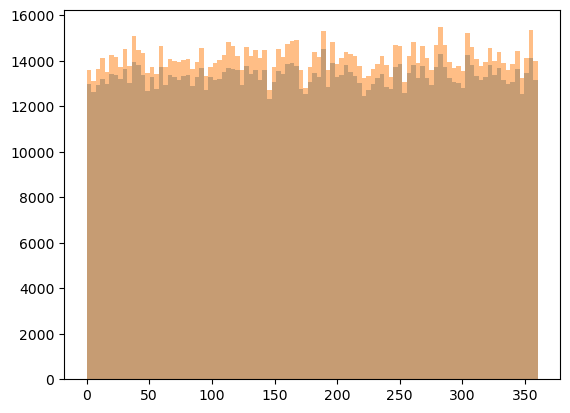

In [ ]:
import matplotlib.pyplot as pl
pl.figure()
_ = pl.hist(halo_catalog['ra'], bins=100, alpha=0.5, label='Halos')
_ = pl.hist(final_galaxy_catalog_cpu[:,0], bins=100, alpha=0.5, label='Halos')
# 

# _ = pl.hist(halo_catalog['dec'], bins=100, alpha=0.5, label='Halos')
# _ = pl.hist(final_galaxy_catalog_cpu[:,1], bins=100, alpha=0.5, label='Halos')



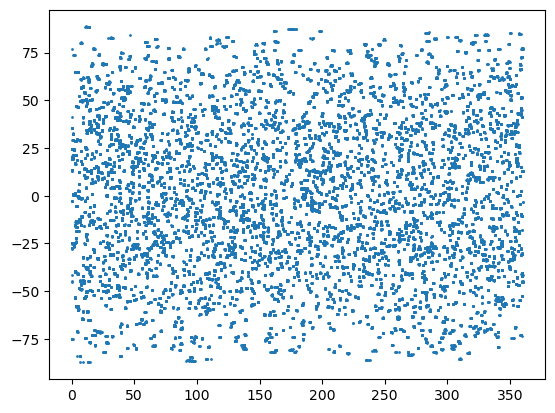

In [28]:
import matplotlib.pyplot as pl
pl.figure()
pl.scatter(final_galaxy_catalog_cpu[:40000,0], final_galaxy_catalog_cpu[:40000,1], s=1)
# pl.ylim(-95, -85)



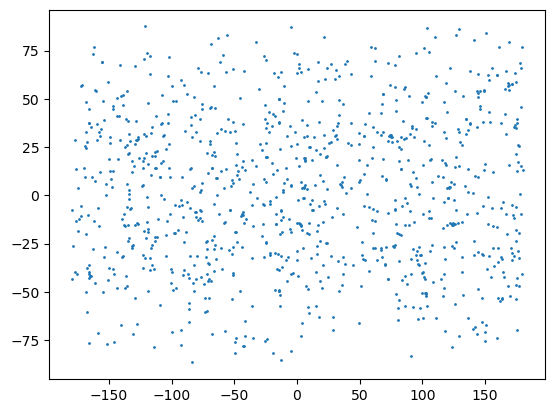

In [49]:
import matplotlib.pyplot as pl
pl.figure()
pl.scatter(halo_catalog['ra'][:1000], halo_catalog['dec'][:1000], s=1)
# pl.ylim(-95, -85)


In [29]:
import treecorr




In [33]:
# create a random catalog:
nrandom = 100000
rand_ra = np.random.uniform(0, 360, nrandom)
# calculate random dec with uniform cos(dec):
u = np.random.uniform(-1, 1, nrandom)
rand_dec = np.arcsin(u) * 180/np.pi

cat = treecorr.Catalog(ra=final_galaxy_catalog_cpu[:,0], dec=final_galaxy_catalog_cpu[:,1], ra_units='deg', dec_units='deg')
rand_cat = treecorr.Catalog(ra=rand_ra, dec=rand_dec, ra_units='deg', dec_units='deg')

# Set up the NNCorrelation object
dd = treecorr.NNCorrelation(min_sep=0.01, max_sep=10.0, nbins=20, sep_units='deg', bin_slop=0.1)
dd.process(cat)

dr = treecorr.NNCorrelation(min_sep=0.01, max_sep=10.0, nbins=20, sep_units='deg', bin_slop=0.1)
dr.process(cat, rand_cat)

rr = treecorr.NNCorrelation(min_sep=0.01, max_sep=10.0, nbins=20, sep_units='deg', bin_slop=0.1)
rr.process(rand_cat)

xi, varxi = dd.calculateXi(rr, dr)



/mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/site-packages/treecorr/util.py:665: FutureWarning: Use of keyword-only arguments as positional arguments is deprecated in the function calculateXi. The following parameters now require an explicit keyword name: ['rr', 'dr']
  warnings.warn(


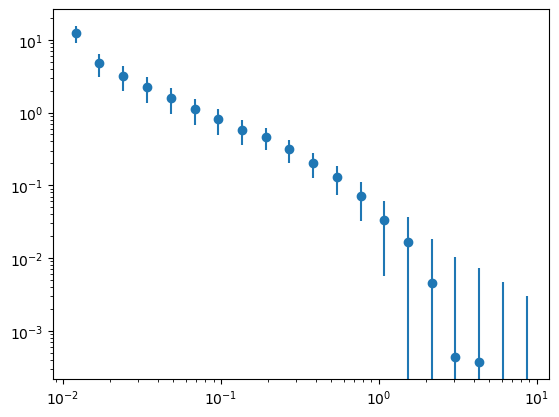

In [34]:
pl.figure()
pl.errorbar(dd.meanr, xi, yerr=np.sqrt(varxi), fmt='o')
pl.xscale('log')
pl.yscale('log')



In [ ]:


# Set JAX to use 64-bit precision for astronomical coordinates if needed
# from jax.config import config
# config.update("jax_enable_x64", True)

print(f"JAX is running on: {jax.default_backend()}")

# --- 1. Setup & Mock Data ---
NUM_HALOS = 1_000_000 # Using 1M for a faster demo; works for 10M
key = PRNGKey(42)
key, subkey1, subkey2, subkey3, subkey4 = split(key, 5)

halo_catalog = {
    'ra': uniform(subkey1, (NUM_HALOS,), minval=0.0, maxval=360.0),
    'dec': uniform(subkey2, (NUM_HALOS,), minval=-90.0, maxval=90.0),
    'z': uniform(subkey3, (NUM_HALOS,), minval=0.1, maxval=1.5),
    'mass': 10**uniform(subkey4, (NUM_HALOS,), minval=11.5, maxval=15.0) # in M_sun/h
}



In [ ]:

# --- 2. Physics Models (HOD, Rvir, etc.) ---
# These are independent of the profile shape logic.

@jit
def get_hod_params(mass, z):
    """Placeholder HOD model."""
    log_m = jnp.log10(mass)
    m_min = 12.0
    m1_prime = 13.5
    mean_ncen = 0.5 * (1 + jax.scipy.special.erf((log_m - m_min) / 0.2))
    mean_nsat = jnp.where(log_m > m_min, mean_ncen * ((mass / (10**m1_prime))**1.0), 0.0)
    return mean_ncen, mean_nsat

@jit
def mass_to_rvir(mass, z):
    """Placeholder to get virial radius in physical kpc/h."""
    omega_m_z = 0.3 * (1+z)**3 / (0.3 * (1+z)**3 + 0.7)
    delta_c = 18 * jnp.pi**2 + 82 * (omega_m_z - 1) - 39 * (omega_m_z - 1)**2
    rho_crit_h = 2.775e11
    rho_mean = rho_crit_h * 0.3
    rvir_mpc = (3 * mass / (4 * jnp.pi * delta_c * rho_mean * (1+z)**3))**(1/3)
    return rvir_mpc * 1000

@jit
def angular_diameter_distance(z):
    """Placeholder for angular diameter distance in physical Mpc/h."""
    H0 = 100.0
    c = 299792.458
    return (c * z / H0) / (1 + z)

# --- 3. Pre-computation of the Inverse CDF (PPF) from a 3D table ---

def create_mock_profile_table(mass_grid, z_grid, x_grid):
    """
    Creates a mock 3D density profile table rho(mass, z, radius).
    In your real application, you would load your data here.
    This example uses the NFW profile to generate the table.
    """
    # NFW helper functions for table generation
    def get_concentration(mass, z):
        return 9.0 * (mass / 1e12)**-0.1 * (1.0 + z)**-0.4
    
    def nfw_density(x, c):
        cx = c * x
        return 1.0 / (cx * (1.0 + cx)**2)

    # Vectorize to compute concentration on the (M, z) grid
    v_get_c = vmap(vmap(get_concentration, in_axes=(0, None)), in_axes=(None, 0))
    c_table = v_get_c(mass_grid, z_grid) # Shape: (num_mass, num_z)

    # Now create the 3D density table
    # We want rho(m, z, x) = nfw_density(x, c(m, z))
    c_table_3d = c_table[:, :, jnp.newaxis]
    x_grid_3d = x_grid[jnp.newaxis, jnp.newaxis, :]
    
    profile_table = nfw_density(x_grid_3d, c_table_3d)
    return profile_table


@partial(jit)
def create_ppf_interpolator_3d(profile_table, mass_grid, z_grid, x_grid):
    """
    Pre-computes the inverse CDF (PPF) table from a 3D density profile table.
    
    Args:
        profile_table (jnp.ndarray): 3D table of rho(mass, z, radius).
        mass_grid (jnp.ndarray): 1D array of mass points.
        z_grid (jnp.ndarray): 1D array of redshift points.
        x_grid (jnp.ndarray): 1D array of normalized radius points.
        
    Returns:
        A dictionary containing the grids needed for 3D interpolation.
    """
    # Calculate the radial PDF: P(x) ~ rho(x) * x^2
    pdf_table = profile_table * x_grid**2

    # Numerically integrate along the radius axis (axis=2) to get the CDF
    cdf_table_unnormalized = cumulative_trapezoid(pdf_table, x_grid, initial=0.0, axis=2)

    # Normalize each CDF to run from 0 to 1
    norm = cdf_table_unnormalized[:, :, -1, jnp.newaxis]
    cdf_table = cdf_table_unnormalized / jnp.maximum(norm, 1e-9)
    
    return {
        "mass_grid": mass_grid,
        "z_grid": z_grid,
        "x_grid": x_grid,
        "cdf_table": cdf_table # Shape: (num_mass, num_z, num_x)
    }

# --- 4. Satellite Sampling using the 3D PPF table ---

@partial(jit, static_argnames=['ppf_interpolator'])
def sample_radii_from_ppf_3d(key, num_samples, mass, z, ppf_interpolator):
    """
    Samples radii by interpolating the pre-computed 3D PPF table.
    """
    mass_grid = ppf_interpolator["mass_grid"]
    z_grid = ppf_interpolator["z_grid"]
    x_grid = ppf_interpolator["x_grid"]
    cdf_table = ppf_interpolator["cdf_table"] # Shape: (M, z, x)
    
    # 1. Generate uniform random numbers for the CDF values to look up
    u = uniform(key, (num_samples,))

    # 2. Interpolate the CDF to get the curve for this halo's (mass, z)
    # Use interpax.interp2d to get the CDF values at all x_grid points
    query_mass_log = jnp.log10(mass)  # Scalar
    query_z = z  # Scalar
    
    grid_mass_log = jnp.log10(mass_grid)
    grid_z = z_grid

    # Interpolate along mass and z axes for each x point
    # We need to vmap over the x axis (axis 2)
    def interpolate_for_x(cdf_slice):
        # cdf_slice has shape (num_mass, num_z)
        return interpax.interp2d(
            xq=jnp.array([query_mass_log]),
            yq=jnp.array([query_z]),
            x=grid_mass_log,
            y=grid_z,
            f=cdf_slice,
            method='linear'
        )[0]  # Extract scalar from array
    
    # Map over the x dimension
    cdf_for_halo = vmap(interpolate_for_x, in_axes=2)(cdf_table)
    
    # 3. Perform inverse 1D interpolation on the resulting curve
    vmap_interp = vmap(jnp.interp, in_axes=(0, None, None))
    x_samples = vmap_interp(u, cdf_for_halo, x_grid)
    
    return x_samples

@partial(jit, static_argnames=['num_sats'])
def place_satellites(key, r_sats_normalized, r_vir, halo_ra, halo_dec, halo_z, halo_mass, num_sats):
    """Places N_sat satellites around a central. Takes normalized radii."""
    r_sats_physical = r_sats_normalized * r_vir
    key_pos, key_vel = split(key)
    
    # Generate angular coordinates
    phi = uniform(key_pos, (num_sats,), minval=0, maxval=2*jnp.pi)
    cos_theta = uniform(split(key_pos, 2)[1], (num_sats,), minval=-1, maxval=1)
    sin_theta = jnp.sqrt(jnp.maximum(1.0 - cos_theta**2, 0.0))  # Prevent numerical issues
    
    # Convert to Cartesian offsets (physical kpc/h)
    dx = r_sats_physical * sin_theta * jnp.cos(phi)
    dy = r_sats_physical * sin_theta * jnp.sin(phi)
    dz = r_sats_physical * cos_theta  # Not used for sky coordinates but computed for completeness
    
    # Convert to angular coordinates
    dist_a_kpc = angular_diameter_distance(halo_z) * 1000
    rad_to_deg = 180.0 / jnp.pi
    
    d_ra_rad = dx / dist_a_kpc
    d_dec_rad = dy / dist_a_kpc
    
    # Apply proper coordinate transformations
    sat_ra = halo_ra + (d_ra_rad * rad_to_deg) / jnp.cos(jnp.deg2rad(halo_dec))
    sat_dec = halo_dec + d_dec_rad * rad_to_deg
    
    # Handle RA wrapping
    sat_ra = jnp.mod(sat_ra, 360.0)
    
    # Use physically-motivated velocity dispersion from Evrard et al. 2008
    sigma_v = 106.2 * (halo_mass / 1e12)**(1/3)
    peculiar_velocity = normal(key_vel, (num_sats,)) * sigma_v
    c_light = 299792.458
    sat_z = halo_z + (peculiar_velocity / c_light) * (1 + halo_z)
    
    return sat_ra, sat_dec, sat_z


# --- 5. Core Logic for a Single Halo ---

@partial(jit, static_argnames=['max_gals', 'ppf_interpolator'])
def populate_one_halo(key, halo_ra, halo_dec, halo_z, halo_mass, max_gals, ppf_interpolator):
    """Processes a single halo to produce a catalog of galaxies with padding."""
    key_hod, key_sat_pos = split(key)
    
    mean_ncen, mean_nsat = get_hod_params(halo_mass, halo_z)
    ncen = jnp.clip(poisson(key_hod, mean_ncen), 0, 1)
    nsat = poisson(split(key_hod, 2)[1], mean_nsat)
    
    # Ensure we don't exceed our padding limits
    nsat = jnp.minimum(nsat, max_gals - 1)

    pad_value = -1.0
    gal_catalog = jnp.full((max_gals, 6), pad_value)
    gal_catalog = gal_catalog.at[:, 5].set(0.0)

    # Place central galaxy
    central_valid = jnp.where(ncen > 0, 1.0, 0.0)
    gal_catalog = gal_catalog.at[0].set(jnp.array([halo_ra, halo_dec, halo_z, halo_mass, 1.0, central_valid]))

    # --- Satellite Placement using 3D PPF ---
    r_vir = mass_to_rvir(halo_mass, halo_z)
    
    # Sample radii - always sample max_gals-1 but only use nsat of them
    r_sats_normalized = sample_radii_from_ppf_3d(
        key_sat_pos, max_gals - 1, halo_mass, halo_z, ppf_interpolator
    )
    
    sats_ra, sats_dec, sats_z = place_satellites(
        split(key_sat_pos, 2)[1], r_sats_normalized, r_vir, halo_ra, halo_dec, halo_z, halo_mass, max_gals - 1
    )
    
    # Create mask for valid satellites
    sat_indices = jnp.arange(1, max_gals)
    sat_mask = (sat_indices <= nsat) & (ncen > 0)
    
    # Fill satellite data
    gal_catalog = gal_catalog.at[1:, 0].set(jnp.where(sat_mask, sats_ra, pad_value))
    gal_catalog = gal_catalog.at[1:, 1].set(jnp.where(sat_mask, sats_dec, pad_value))
    gal_catalog = gal_catalog.at[1:, 2].set(jnp.where(sat_mask, sats_z, pad_value))
    gal_catalog = gal_catalog.at[1:, 3].set(jnp.where(sat_mask, halo_mass, pad_value))
    gal_catalog = gal_catalog.at[1:, 4].set(0.0)  # Is_Central = 0 for satellites
    gal_catalog = gal_catalog.at[1:, 5].set(jnp.where(sat_mask, 1.0, 0.0))
    
    return gal_catalog


In [ ]:

# --- 6. Vectorization and Execution ---

print("--- Step 1: Generating Mock Profile and Pre-computing the 3D PPF interpolator ---")
# Define the grids for our 3D profile table
# IMPORTANT: These must cover the range of your halo catalog
num_mass_bins, num_z_bins, num_x_bins = 50, 40, 500
mass_grid = jnp.logspace(11.5, 15.0, num_mass_bins)
z_grid = jnp.linspace(0.1, 1.5, num_z_bins)
x_grid = jnp.logspace(-4, 0, num_x_bins)  # r/R_vir

# Create the mock density table (replace with loading your data)
mock_rho_table = create_mock_profile_table(mass_grid, z_grid, x_grid)

# Create the PPF interpolator object from the density table
ppf_table_3d = create_ppf_interpolator_3d(mock_rho_table, mass_grid, z_grid, x_grid)
print("3D PPF table created.")


print("\n--- Step 2: Preparing for vectorized population ---")
mean_ncen_all, mean_nsat_all = vmap(get_hod_params)(halo_catalog['mass'], halo_catalog['z'])
max_mean_nsat = jnp.max(mean_nsat_all)
max_gals_per_halo = int(jnp.ceil(max_mean_nsat + 10 * jnp.sqrt(max_mean_nsat))) + 1
print(f"Using a padding size of max_gals = {max_gals_per_halo} per halo.")

# Use partial to bake the static arguments into the function
populator_func = partial(populate_one_halo, max_gals=max_gals_per_halo, ppf_interpolator=ppf_table_3d)
vectorized_populate = vmap(populator_func, in_axes=(0, 0, 0, 0, 0), out_axes=0)
jitted_vectorized_populate = jit(vectorized_populate)

print(f"\n--- Step 3: Populating {NUM_HALOS} halos with galaxies ---")
keys = split(key, NUM_HALOS)
padded_galaxy_catalog = jitted_vectorized_populate(
    keys,
    halo_catalog['ra'],
    halo_catalog['dec'],
    halo_catalog['z'],
    halo_catalog['mass']
)
padded_galaxy_catalog.block_until_ready()
print("Population complete.")

# --- 7. Post-processing ---
print("\n--- Step 4: Filtering padded catalog ---")
flat_padded_catalog = padded_galaxy_catalog.reshape(-1, 6)
valid_mask = flat_padded_catalog[:, 5] > 0.5
final_galaxy_catalog = flat_padded_catalog[valid_mask]

print(f"Generated a final catalog with {final_galaxy_catalog.shape[0]} galaxies.")
print("\n--- Final Galaxy Catalog (first 10 rows) ---")
print("Columns: RA, Dec, Redshift, Host Halo Mass, Is_Central (1=yes), Is_Valid (all 1s)")
print(final_galaxy_catalog[:10])




In [7]:
import pickle as pk
ldir = '/mnt/home/spandey/ceph/paste_godmax/GODMAX/results/backlight'
# zval = 0.059
# zval = 0.08
# zval = 0.102
# zval = 0.124
# zval = 0.147
# zval = 0.276
zval = 0.196
df = pk.load(open(f'{ldir}/allmaps_sim_B12_testv11_nside_1024_z_{zval}_split_0_1.pkl','rb'))

df.keys()


dict_keys(['mock_gals_all', 'map_rhom', 'map_ymap', 'map_ksz', 'map_tau'])

In [8]:
map_rhom = df['map_rhom']  # in Msun/kpc^2/h
map_ymap = df['map_ymap']  # in dimensionless Compton-y
map_ksz = df['map_ksz']  # in dimensionless kSZ
map_tau = df['map_tau']  # in dimensionless tau
mock_gals = df['mock_gals_all']  # in RA, Dec, z, M200c, Is_Central, Is_Valid



/tmp/ipykernel_1224825/2599685979.py:3: RuntimeWarning: divide by zero encountered in log10
  hp.mollview(np.log10(map_rhom), title=r'$\rho_{\rm matter}$')


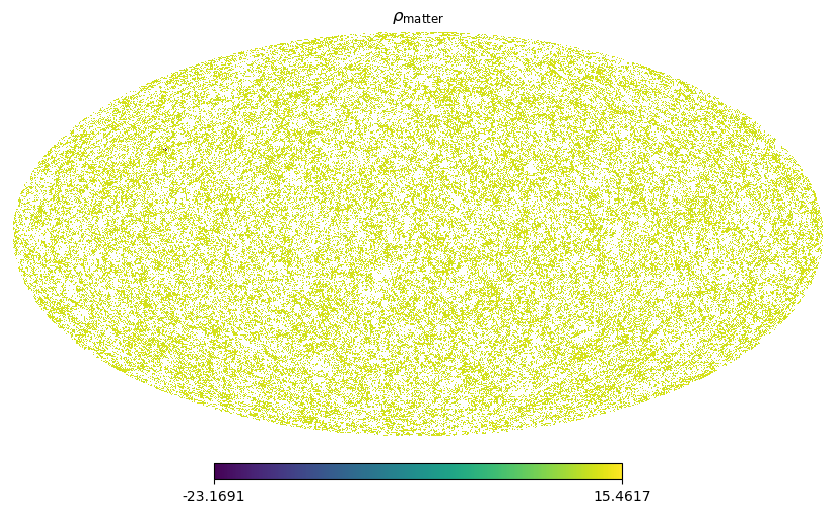

In [10]:
import healpy as hp
import numpy as np
hp.mollview(np.log10(map_rhom), title=r'$\rho_{\rm matter}$')


/tmp/ipykernel_1224825/1009944096.py:1: RuntimeWarning: divide by zero encountered in log10
  hp.mollview(np.log10(map_ksz), title=r'kSZ')
/tmp/ipykernel_1224825/1009944096.py:1: RuntimeWarning: invalid value encountered in log10
  hp.mollview(np.log10(map_ksz), title=r'kSZ')


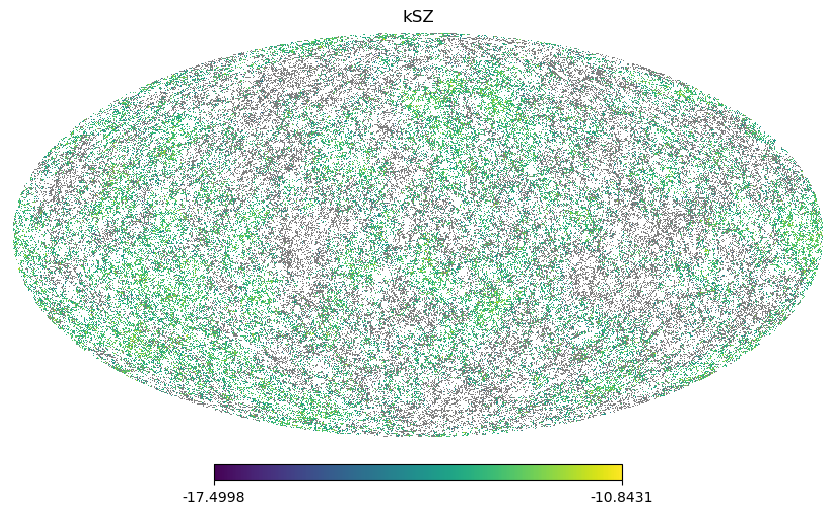

In [13]:
hp.mollview(np.log10(map_ksz), title=r'kSZ')



/tmp/ipykernel_1224825/4105417194.py:1: RuntimeWarning: divide by zero encountered in log10
  hp.mollview(np.log10(map_ymap), title=r'tSZ')


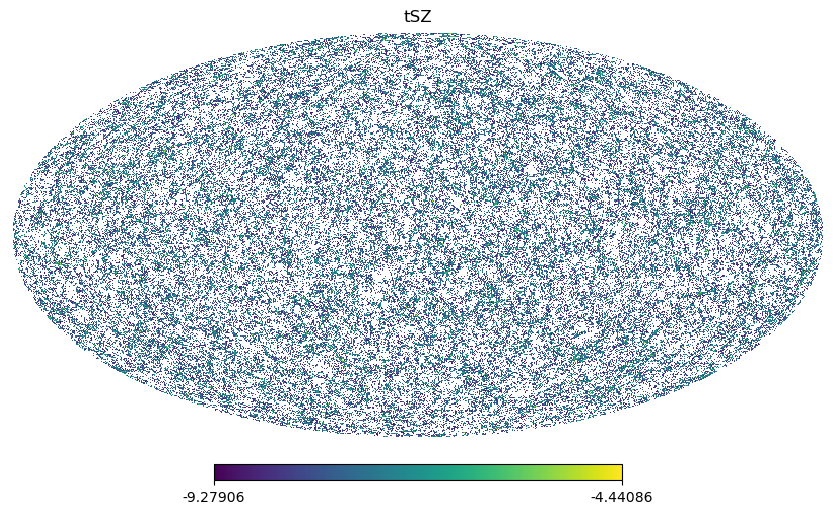

In [15]:
hp.mollview(np.log10(map_ymap), title=r'tSZ')



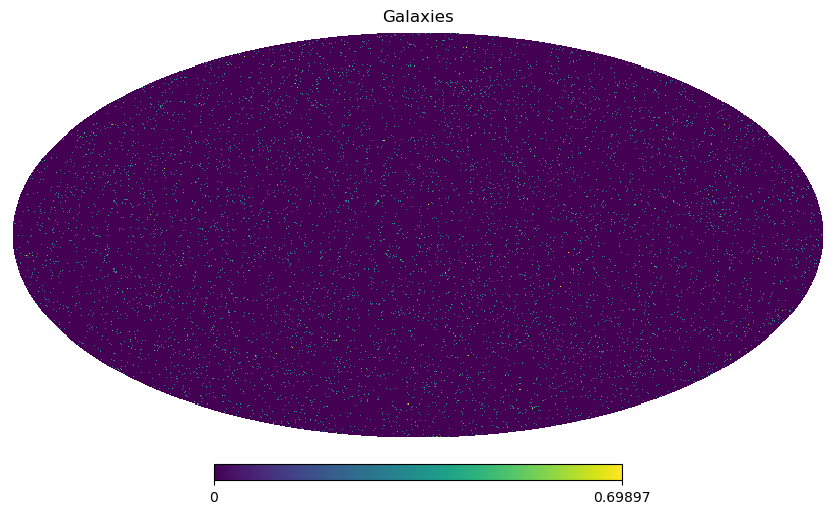

In [19]:
nside = hp.get_nside(map_rhom)
ra_mock_gals = mock_gals[0][:,0]
dec_mock_gals = mock_gals[0][:,1]
ind_gals = hp.ang2pix(nside, ra_mock_gals, dec_mock_gals, lonlat=True)
map_gals = np.bincount(ind_gals, minlength=len(map_rhom))
hp.mollview(np.log10(map_gals+1), title='Galaxies')


In [24]:
delta_gals = (map_gals/np.mean(map_gals)) - 1
Cl_gy = hp.anafast(delta_gals, map_ymap)
Cl_gtau = hp.anafast(delta_gals, map_tau)



In [25]:
import matplotlib.pyplot as pl


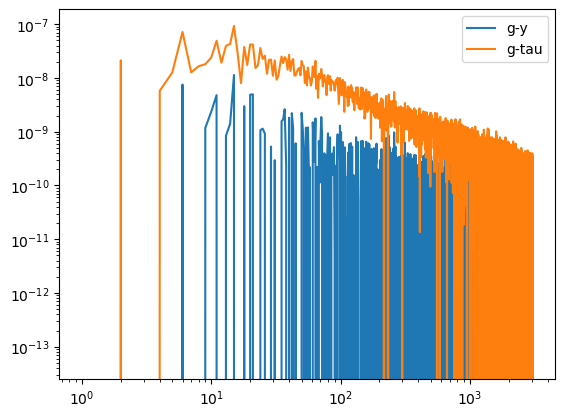

In [26]:
pl.figure()
pl.loglog(Cl_gy, label='g-y')
pl.loglog(Cl_gtau, label='g-tau')
pl.legend()
